# PENGWIN, semana 10: pipeline completo, fragmentos, distancia, SAM y métricas

Proyecto Integrador Corte 2, Analítica de Datos, UAO 2026-2. Uso exclusivamente académico: no es un
dispositivo médico ni ha sido validado clínicamente.

Entregable de la semana 10 (documento base, §6): *pipeline completo detección → NMS → segmentación de
instancia → clasificación por pertenencia; entrenamiento completo; medición de distancia de
separación; comparación contra SAM; métricas de la sección 5.*

Contenido:

- **A. Entregables de la semana y dónde está la evidencia**
- **B. El pipeline, ejecutado paso a paso sobre un caso sintético**
- 1-9. Pipeline base: modelo v2, separación por distancia, resultados en test, distancia, SAM, latencia
- **10. El modelo actual: capas y parámetros**
- **11. Dónde está el techo: oráculos**
- **12. Campaña de mejora: validación cruzada de 5 folds**
- **13. Segunda pasada por hueso a resolución nativa**
- **14. Un defecto en la aumentación, encontrado y corregido**
- **15. Métricas de la sección 5 frente a su objetivo**
- **16. Qué no funcionó, limitaciones y pendientes**

Lee los resultados guardados en `reports/`; corre en segundos sin datos ni GPU. Las secciones A, B y
10 ejecutan código del paquete `pengwin`. El informe completo está en `reports/informe_semana10.md`.

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.precision", 3)


def find_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "03_src" / "pengwin").is_dir():
            return p
    raise FileNotFoundError("No se encontró la raíz del repositorio")


ROOT = find_root()
sys.path.insert(0, str(ROOT / "03_src"))
REP = ROOT / "reports"
FIG = REP / "figures" / "semana10"
FIG.mkdir(parents=True, exist_ok=True)
CACHE = Path(os.environ.get("PENGWIN_CACHE_DIR", ROOT / "data_processed"))
CKPT = ROOT / "checkpoints" / "v2_last" / "best.pth"
try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
LIVE = HAS_TORCH and CKPT.exists() and (CACHE / "084" / "meta.json").exists()

C = {"SA": "#2a78d6", "LI": "#eb6834", "RI": "#1baf7a"}
INK, INK2, MUTED, GRID, AXIS, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 8, "font.size": 9, "lines.linewidth": 2,
})


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")


def read_json(p):
    return json.loads(Path(p).read_text(encoding="utf-8"))

<!-- y4xul -->
## A. Entregables de la semana 10

| entregable (§6) | estado | evidencia |
|---|---|---|
| Detección → NMS | hecho | sección B.1; `detection/grid.py`, `detection/nms.py`; mAP en secciones 2 y 12 |
| Segmentación de instancia | hecho | secciones B.2, 4 y 13; `postprocess/instances.py` |
| Clasificación por pertenencia | hecho | sección B.2: cada fragmento hereda el hueso de su región |
| Entrenamiento completo | hecho | secciones 2 y 12; `reports/train/` |
| Distancia de separación en mm | hecho | secciones B.3 y 6; `measurement/separation.py` |
| Comparación contra SAM | hecho con el modelo base | sección 7; `reports/sam/base_test.json` |
| Métricas de la sección 5 | 6 de 7 cumplidas | sección 15 |

La celda siguiente comprueba que la evidencia versionada existe.

In [2]:
# y4xul
evidencia = {
    "Cabeza de detección y NMS propias": ["03_src/pengwin/detection/grid.py", "03_src/pengwin/detection/nms.py"],
    "Formación de instancias": ["03_src/pengwin/postprocess/instances.py", "03_src/pengwin/inference/volume.py"],
    "Segunda pasada por hueso": ["03_src/pengwin/data/two_pass.py", "configs/tuning/y8_refine_eff.yaml"],
    "Distancia de separación": ["03_src/pengwin/measurement/separation.py"],
    "Entrenamiento (historial y config)": ["reports/train/base.json", "reports/train/v2.json"],
    "Métricas por fragmento en test": ["reports/fragments/v2_last_test_edt.json"],
    "Comparación con SAM": ["reports/sam/base_test.json"],
    "Latencia CPU / GPU": ["reports/latency/base.json"],
    "Validación cruzada y decisiones": ["reports/tuning/y4xul/resultados.json", "reports/tuning/y4xul/REGISTRO.md",
                                        "reports/informe_semana10.md"],
    "Pruebas automáticas": ["06_tests/test_boxes_nms.py", "06_tests/test_instances_separation.py",
                            "06_tests/test_separation_convention.py", "06_tests/test_role3.py", "06_tests/test_two_pass.py"],
}
filas = [{"entregable": k, "archivos": len(v), "presentes": sum((ROOT / f).exists() for f in v)} for k, v in evidencia.items()]
tabla = pd.DataFrame(filas)
tabla["ok"] = np.where(tabla.archivos == tabla.presentes, "sí", "FALTA")
display(tabla)
Y4 = read_json(REP / "tuning" / "y4xul" / "resultados.json")

,entregable,archivos,presentes,ok
0,Cabeza de detección y NMS propias,2,2,sí
1,Formación de instancias,2,2,sí
2,Segunda pasada por hueso,2,2,sí
3,Distancia de separación,1,1,sí
4,Entrenamiento (historial y config),2,2,sí
5,Métricas por fragmento en test,1,1,sí
6,Comparación con SAM,1,1,sí
7,Latencia CPU / GPU,1,1,sí
8,Validación cruzada y decisiones,3,3,sí
9,Pruebas automáticas,5,5,sí


<!-- y4xul -->
## B. El pipeline, paso a paso, sobre un caso sintético

Las secciones 1-9 muestran el pipeline sobre pacientes reales con resultados guardados. Aquí se
ejecuta **el mismo código** sobre un caso construido a mano, donde la respuesta correcta se conoce:
un coxal izquierdo partido en un fragmento principal y dos secundarios (uno pegado al principal y
otro separado 6 mm), y un coxal derecho entero.

### B.1 Detección → NMS

La cabeza de detección propone una caja por celda del grid. La NMS propia (`detection/nms.py`) se
queda con la mejor de cada hueso.

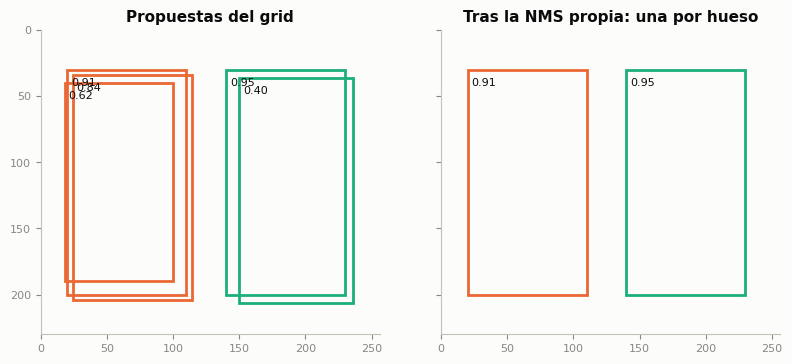

5 propuestas -> 2 cajas; puntajes conservados: [0.95, 0.91]


In [3]:
# y4xul
import torch
from pengwin.detection.nms import batched_nms

# tres propuestas para el coxal izquierdo (clase 1) y dos para el derecho (clase 2), en píxeles
cajas = torch.tensor([[20., 30, 110, 200], [24, 34, 114, 204], [18, 40, 100, 190], [140, 30, 230, 200], [150, 36, 236, 206]])
puntajes = torch.tensor([0.91, 0.84, 0.62, 0.95, 0.40])
clases = torch.tensor([1, 1, 1, 2, 2])
quedan = batched_nms(cajas, puntajes, clases, 0.5, 1)

fig, axs = plt.subplots(1, 2, figsize=(8.4, 3.6), sharex=True, sharey=True)
for ax, idx, t in ((axs[0], range(5), "Propuestas del grid"), (axs[1], quedan.tolist(), "Tras la NMS propia: una por hueso")):
    for i in idx:
        x0, y0, x1, y1 = cajas[i].tolist()
        col = C["LI"] if clases[i] == 1 else C["RI"]
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=col, linewidth=2))
        ax.text(x0 + 3, y0 + 12, f"{puntajes[i]:.2f}", color=INK, fontsize=8)
    ax.set_xlim(0, 256); ax.set_ylim(230, 0); ax.set_aspect("equal"); ax.set_title(t); ax.grid(False)
plt.tight_layout(); plt.show()
print(f"{len(cajas)} propuestas -> {len(quedan)} cajas; puntajes conservados: {[round(float(puntajes[i]), 2) for i in quedan]}")

<!-- y4xul -->
### B.2 Segmentación de instancia y clasificación por pertenencia

La red da, por vóxel, la región (qué hueso es) y dos señales de instancia: el borde de fractura y el
papel (principal o secundario). Las instancias se forman en 3D, **hueso por hueso**: por eso un
fragmento no puede cambiar de hueso, y su etiqueta (1-10 sacro, 11-20 coxal izquierdo, 21-30 coxal
derecho) lleva la pertenencia.

Se compara el método por distancia (`edt`) con el método por papel (`role`) cuando la red **no marca
el borde**, que es el fallo medido en los datos reales.

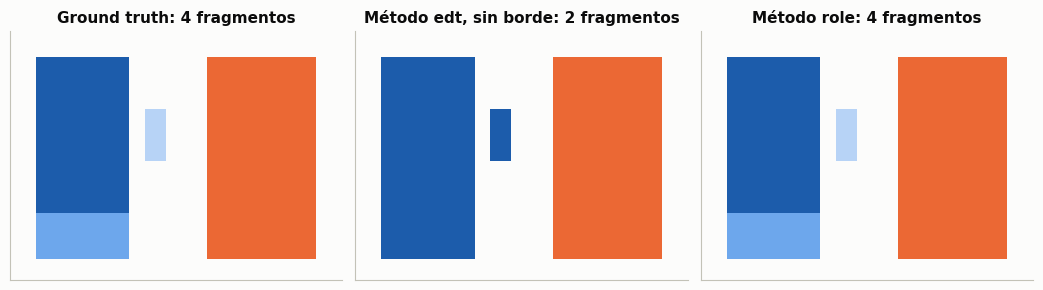

edt   etiquetas: [11, 21]
role  etiquetas: [11, 12, 13, 21]


In [4]:
# y4xul
from pengwin.data.targets import region_of, role_target
from pengwin.postprocess.instances import separate_instances

sp = (1.0, 1.0, 1.0)                                  # mm por vóxel (z, y, x)
gt = np.zeros((16, 96, 128), np.uint8)
gt[2:14, 10:70, 10:46] = 11                           # coxal izq., principal
gt[2:14, 70:88, 10:46] = 12                           # secundario PEGADO al principal
gt[2:14, 30:50, 52:60] = 13                           # secundario separado 6 mm
gt[2:14, 10:88, 76:118] = 21                          # coxal der., entero
region = region_of(gt)                                # lo que da la etapa 1
papel = (role_target(gt) == 2).astype(np.float32)     # salida "papel", aquí perfecta
sin_borde = np.zeros(gt.shape, np.float32)            # la cabeza de borde no marca nada

por_edt = separate_instances(region, sin_borde, sp, method="edt", seed_depth_mm=5.0, edge_threshold=0.2)
por_papel = separate_instances(region, sin_borde, sp, method="role", role=papel, min_fragment_cm3=0.05)

cmap = mpl.colors.ListedColormap([SURF, "#1c5cab", "#6da7ec", "#b7d3f6", "#eb6834"])
idx = {0: 0, 11: 1, 12: 2, 13: 3, 21: 4}
fig, axs = plt.subplots(1, 3, figsize=(10.5, 3.2))
for ax, vol, t in zip(axs, (gt, por_edt, por_papel), ("Ground truth", "Método edt, sin borde", "Método role")):
    ax.imshow(np.vectorize(lambda v: idx.get(int(v), 3))(vol[8]), cmap=cmap, vmin=0, vmax=4, interpolation="nearest")
    ax.set_title(f"{t}: {len(np.unique(vol)) - 1} fragmentos"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()
for nombre, vol in (("edt", por_edt), ("role", por_papel)):
    print(f"{nombre:5s} etiquetas: {sorted(int(v) for v in np.unique(vol) if v)}")

<!-- y4xul -->
Sin borde, `edt` deja el coxal izquierdo como **un solo fragmento**: funde el secundario pegado, que
es el modo de falla principal en los datos reales (el 88,7 % de los secundarios toca a su
principal), y pierde el delgado, que mide 8 mm de ancho y no deja semilla al erosionar 5 mm. `role`
recupera los dos porque no depende del borde ni de la erosión.

### B.3 Distancia de separación en mm y métricas por fragmento

`distance_transform_edt` con el spacing del volumen (§3.3). Se calcula igual sobre el ground truth y
sobre la predicción.

In [5]:
# y4xul
from pengwin.evaluation.fragment_metrics import distance_comparison, match_fragments, summarize
from pengwin.measurement.separation import separation_table

sp_real = (1.0, 0.8, 0.8)                             # spacing anisotrópico, como en un CT
print("Distancias en el ground truth:")
display(pd.DataFrame(separation_table(gt, sp_real))[["region", "label", "volume_cm3", "dist_mm", "in_contact"]])
filas = {}
for nombre, vol in (("edt, sin borde", por_edt), ("role", por_papel)):
    fr = match_fragments(gt, vol, sp_real)
    s = summarize(fr, distance_comparison(gt, vol, sp_real, fr))
    filas[nombre] = {"Dice por fragmento": s["dice_fragmento"], "IoU por fragmento": s["iou_fragmento"],
                     "Dice principal": s["dice_principal"], "Dice secundario": s["dice_secundario"],
                     "secundarios recuperados (%)": s["recuperados_secundarios_%"], "MAE distancia (mm)": s["mae_distancia_mm"]}
display(pd.DataFrame(filas).T.round(3))

Distancias en el ground truth:


,region,label,volume_cm3,dist_mm,in_contact
0,LI,12,4.977,0.8,True
1,LI,13,1.229,5.6,False


,Dice por fragmento,IoU por fragmento,Dice principal,Dice secundario,secundarios recuperados (%),MAE distancia (mm)
"edt, sin borde",0.461,0.432,0.921,0.0,0.0,NaN
role,1.000,1.000,1.000,1.0,100.0,0.0


<!-- y4xul -->
El fragmento separado mide 6 px × 0,8 mm = 4,8 mm, que es lo que devuelve la tabla; el que está
pegado da una distancia igual a un vóxel y queda marcado "en contacto". Un fragmento que no se
recupera cuenta 0 en el Dice por fragmento: por eso `edt` sin borde cae aunque todos los vóxeles
estén bien clasificados como hueso.

Hasta aquí, el pipeline completo sobre un caso de respuesta conocida. Las secciones 1 a 9 lo
muestran sobre pacientes reales.

## 1. Qué hicimos en la semana

La semana 9 dejó un modelo que dice qué píxeles son de cada hueso. Esta semana pasamos a los **fragmentos**:

1. El modelo recorre todos los cortes del paciente y se arma el volumen de regiones y bordes de fractura.
2. Cada hueso se divide en fragmentos (sección 4).
3. Todo se devuelve al tamaño original del `.mha`.
4. Se mide la distancia de cada fragmento al principal en mm, con `distance_transform_edt` y el spacing del header.
5. Se compara contra el ground truth, contra SAM, y se mide la latencia.

## 2. Modelo v2

Entrenamos un segundo modelo en ANTON, de 40 épocas, con cuatro cambios:

- **Borde de fractura en 3D:** antes se calculaba dentro de cada corte y no veía los contactos entre cortes.
- **Dropout espacial** (`Dropout2d`, p = 0,1) en los bloques 3 y 4 y en el decodificador. Apaga canales completos.
- **γ aprendible** en el CBAM y en el cuello, para medir cuánto se usa cada parte (sección 9).
- **λ recalibrados**, porque la pérdida de borde cambió.

Comparación en test con las métricas de la semana 9:

In [6]:
ev = {n: read_json(REP / "eval" / f"{r}_test.json")["metricas"] for r, n in (("base", "Base"), ("v2_last", "v2"))}
keys = ["mAP@0.50", "mAP@[.50:.95]", "IoU_promedio", "dice_hueso", "dice_SA", "cls_f1_macro"]
pd.DataFrame({n: {k: m[k] for k in keys} for n, m in ev.items()}).round(3)

,Base,v2
mAP@0.50,0.977,0.980
mAP@[.50:.95],0.841,0.864
IoU_promedio,0.911,0.919
dice_hueso,0.968,0.971
dice_SA,0.954,0.961
cls_f1_macro,0.993,0.993


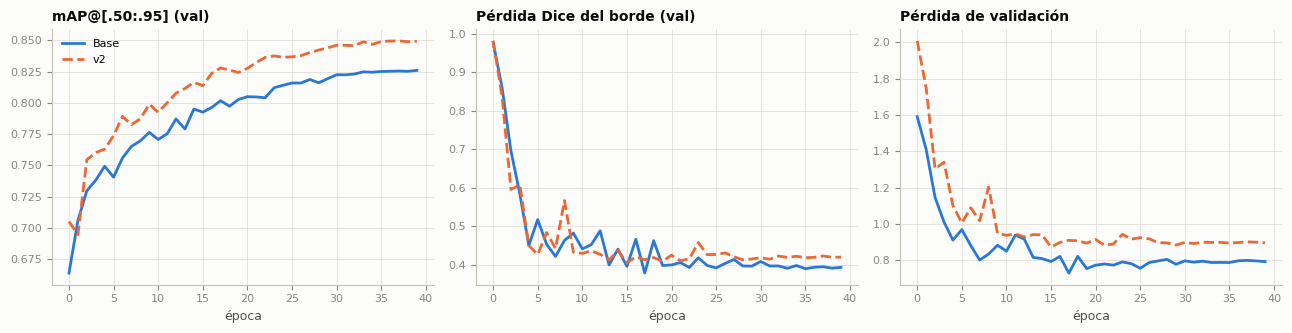

In [7]:
H = {n: pd.read_csv(REP / "train" / f"{r}_history.csv") for r, n in (("base", "Base"), ("v2", "v2"))}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, (col, title) in zip(axes, (("mAP@[.50:.95]", "mAP@[.50:.95] (val)"), ("val_edge_dice", "Pérdida Dice del borde (val)"),
                                   ("val_total", "Pérdida de validación"))):
    for (n, h), (color, ls) in zip(H.items(), ((C["SA"], "-"), (C["LI"], "--"))):
        ax.plot(h.epoch, h[col], color=color, ls=ls, label=n)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_xlabel("época")
axes[0].legend()
fig.tight_layout()
savefig(fig, "01_curvas_base_v2")
plt.show()

v2 afina mejor las cajas (mAP@[.5:.95] de 0,841 a 0,864 en test). Las pérdidas de validación no se comparan directo entre los dos, porque el objetivo del borde cambió (3D, con otro peso).

## 3. Por qué no se separaban los fragmentos

Al principio separábamos cada hueso así: quitar los píxeles de borde y tomar los pedazos que quedaran. Con eso, casi ningún fragmento secundario salía separado (12 % con el modelo base, 10 % con v2).

Para encontrar la causa probamos cruzando lo predicho con lo real:

| Región usada | Borde usado | Secundarios recuperados |
|---|---|---|
| predicha | predicho | 8 % |
| predicha | real | 11 % |
| real | predicho | 12 % |
| real | real | 71 % |

Fallan las dos cosas a la vez:
- el borde predicho solo encuentra el 15 % del borde real;
- la región predicha "rellena" las grietas entre fragmentos y los vuelve a unir.

## 4. Separación por distancia

En vez de depender solo del borde, buscamos el **centro** de cada fragmento:

1. En cada hueso se calcula a cuántos mm está cada vóxel del borde más cercano (`distance_transform_edt`).
2. Las zonas a más de 5 mm del borde son semillas, y cada semilla es un fragmento. Las grietas y las uniones delgadas nunca llegan a 5 mm, así que separan aunque la red las haya rellenado.
3. Un watershed reparte el resto del hueso entre las semillas.
4. El fragmento más grande es el principal.

Los 5 mm se eligieron en **validación** (no en test):

| Método | Profundidad de semilla | Secundarios recuperados | Dice fragmento |
|---|---|---|---|
| solo borde | — | 1,8 % | 0,531 |
| distancia | 2 mm | 31,0 % | 0,638 |
| distancia | 3 mm | 46,4 % | 0,705 |
| distancia | 4 mm | 61,3 % | 0,765 |
| **distancia** | **5 mm** | **67,3 %** | **0,790** |
| distancia | 6 mm | 59,5 % | 0,764 |
| distancia | 8 mm | 33,3 % | 0,622 |

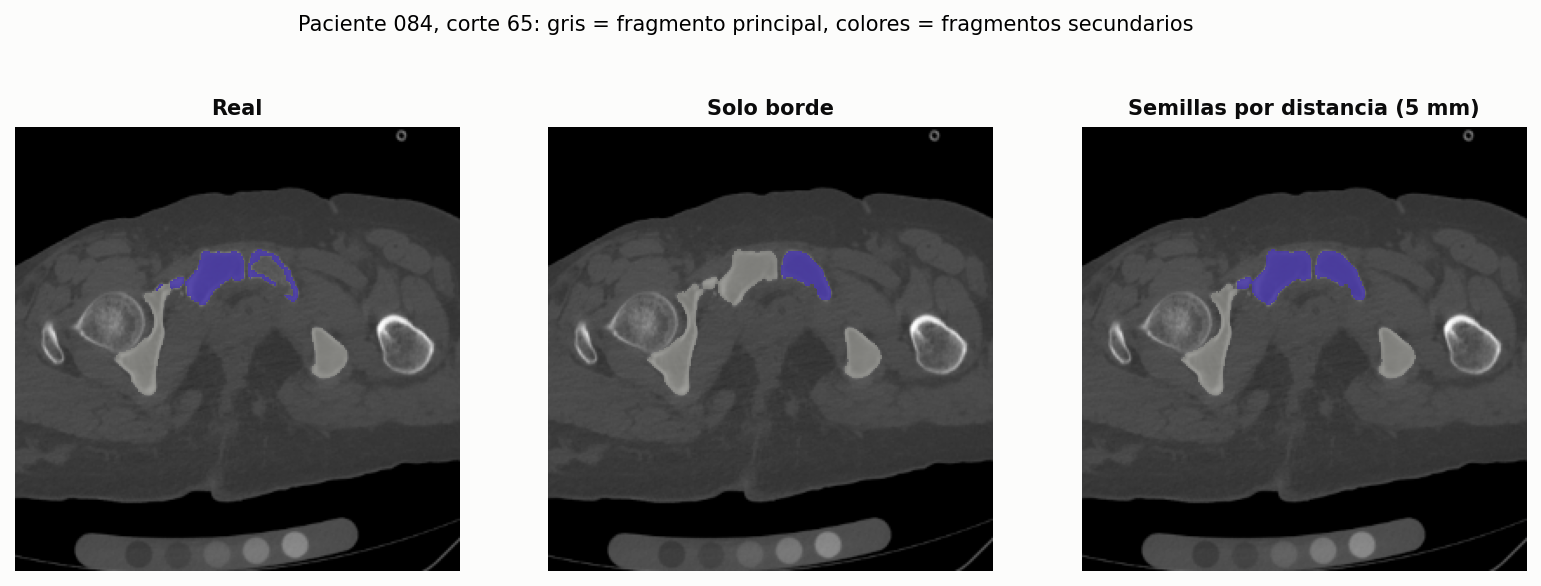

In [8]:
ej_png = FIG / "02_ejemplo_fragmentos.png"
if LIVE:
    from matplotlib.colors import ListedColormap
    from pengwin.data.slice_cache import load_case_cache
    from pengwin.inference.volume import predict_case
    from pengwin.models.pengwin_net import PengwinNet
    from pengwin.postprocess.instances import separate_instances
    from pengwin.utils.config import load_config

    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ck = torch.load(CKPT, map_location="cpu", weights_only=False)
    model = PengwinNet(ck["cfg"]["model"]).to(dev).eval()
    model.load_state_dict(ck["model"])
    pp = load_config(ROOT / "configs" / "base.yaml")["postprocess"]
    case = "084"
    pred = predict_case(model, CACHE, case, ck["cfg"], dev)
    image, label, meta = load_case_cache(CACHE / case)
    sp = (meta["spacing_zyx"][0], meta["pixel_mm"], meta["pixel_mm"])
    solo_borde = separate_instances(pred["semantic"], pred["edge"], sp, 0.5, method="edge")
    distancia = separate_instances(pred["semantic"], pred["edge"], sp, pp["edge_threshold"], method="edt", seed_depth_mm=pp["seed_depth_mm"])
    lab = np.asarray(label)
    # corte con más fragmentos secundarios en el GT
    z = int(np.argmax([((lab[k] % 10) > 1).sum() for k in range(lab.shape[0])]))
    # color: principal gris, secundarios en violeta / rosa / amarillo
    cmap = ListedColormap([(0, 0, 0, 0), (0.55, 0.55, 0.53, 0.75), (0.29, 0.23, 0.65, 0.9), (0.91, 0.48, 0.64, 0.9),
                           (0.93, 0.63, 0.0, 0.9), (0.2, 0.2, 0.2, 0.9)])
    rank = lambda L: np.where(L > 0, np.minimum((L - 1) % 10 + 1, 5), 0)
    fig, ax = plt.subplots(1, 3, figsize=(13, 4.6))
    for a, (L, t) in zip(ax, ((lab, "Real"), (solo_borde, "Solo borde"), (distancia, "Semillas por distancia (5 mm)"))):
        a.imshow(np.asarray(image[z]), cmap="gray")
        a.imshow(rank(L[z]), cmap=cmap, vmin=0, vmax=5, interpolation="nearest")
        a.set_title(t, fontsize=10)
        a.axis("off")
    fig.suptitle(f"Paciente {case}, corte {z}: gris = fragmento principal, colores = fragmentos secundarios", fontsize=10)
    savefig(fig, "02_ejemplo_fragmentos")
    plt.show()
elif ej_png.exists():
    display(Image(filename=str(ej_png), width=950))

## 5. Resultados por fragmento

Test: 15 pacientes, 84 fragmentos reales (45 principales y 39 secundarios). Cada fragmento real se empareja con el predicho que más se le parece, y si no tiene pareja cuenta como Dice 0.

In [9]:
rows = {}
for r, name in (("base_test", "Base, solo borde"), ("v2_test", "v2, solo borde"),
                ("base_test_edt", "Base, distancia"), ("v2_last_test_edt", "v2, distancia")):
    f = REP / "fragments" / f"{r}.json"
    if f.exists():
        g = read_json(f)["global"]
        rows[name] = {"Dice fragmento": g["dice_fragmento"], "IoU fragmento": g["iou_fragmento"],
                      "Dice principal": g["dice_principal"], "Dice secundario": g["dice_secundario"],
                      "Secundarios recuperados %": g["recuperados_secundarios_%"]}
tabla = pd.DataFrame(rows)
tabla["Objetivo"] = ["≥ 0.85", "≥ 0.70", "", "", ""]
tabla.round(3)

,"Base, solo borde","v2, solo borde","Base, distancia","v2, distancia",Objetivo
Dice fragmento,0.545,0.533,0.717,0.725,≥ 0.85
IoU fragmento,0.505,0.493,0.657,0.671,≥ 0.70
Dice principal,0.921,0.920,0.920,0.930,
Dice secundario,0.111,0.086,0.483,0.489,
Secundarios recuperados %,12.821,10.256,51.282,51.282,


In [10]:
f = pd.read_csv(REP / "fragments" / "v2_last_test_edt_fragmentos.csv")
f["tamaño"] = pd.cut(f.volumen_cm3, [0, 5, 20, np.inf], labels=["< 5 cm³", "5-20 cm³", "> 20 cm³"])
f["tipo"] = np.where(f.es_principal, "principal", "secundario")
f.groupby(["tipo", "tamaño"], observed=True).agg(n=("dice", "size"), dice=("dice", "mean"), recuperados=("recuperado", "mean")).round(3)

n   dice  recuperados
tipo       tamaño                          
principal  > 20 cm³  45  0.930        1.000
secundario < 5 cm³    7  0.000        0.000
           5-20 cm³  13  0.506        0.538
           > 20 cm³  19  0.657        0.684

Los fragmentos principales salen bien (Dice 0,93). El Dice por fragmento (0,725) todavía no llega al objetivo de 0,85 por los secundarios: recuperamos la mitad, y los menores de 5 cm³ no reciben semilla con 5 mm de profundidad.

## 6. Distancia de separación en mm

Se mide igual en la predicción y en el ground truth: la distancia mínima de cada secundario al principal de su hueso. Si la distancia es menor o igual que la diagonal del vóxel, el fragmento está "en contacto".

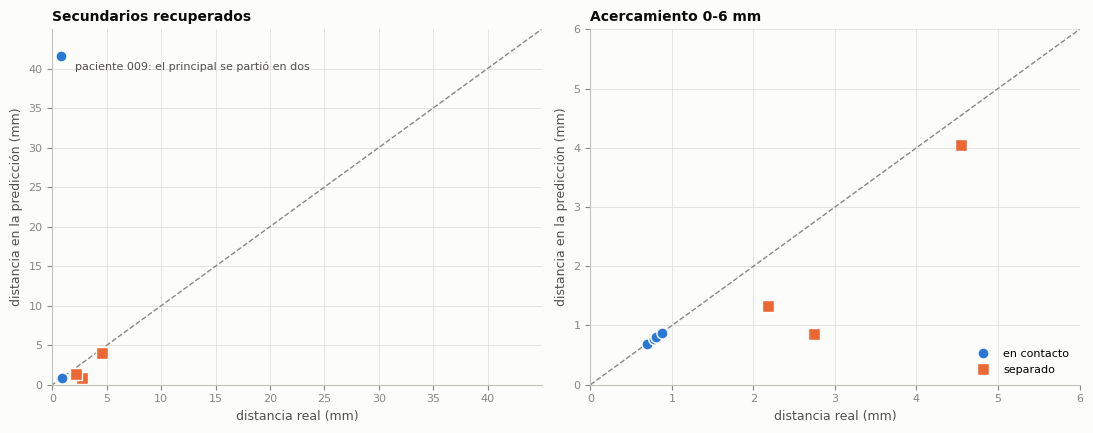

20 secundarios medidos | error medio 2.20 mm | mediana 0.00 mm | sin el caso atípico 0.17 mm


In [11]:
d = pd.read_csv(REP / "fragments" / "v2_last_test_edt_distancias.csv")
dm = d[d.medido]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, lim in zip(axes, (max(dm.dist_gt_mm.max(), dm.dist_pred_mm.max()) * 1.08, 6)):
    ax.plot([0, lim], [0, lim], color=MUTED, lw=1, ls="--")
    for contacto, marker, name in ((True, "o", "en contacto"), (False, "s", "separado")):
        s = dm[dm.contacto_gt == contacto]
        ax.plot(s.dist_gt_mm, s.dist_pred_mm, marker, ms=8, color=C["SA"] if contacto else C["LI"], mec="white",
                label=name, ls="none")
    ax.set(xlabel="distancia real (mm)", ylabel="distancia en la predicción (mm)", xlim=(0, lim), ylim=(0, lim))
peor = dm.loc[dm.error_mm.abs().idxmax()]
axes[0].annotate(f"paciente {int(peor.case_id):03d}: el principal se partió en dos", (peor.dist_gt_mm, peor.dist_pred_mm),
                 xytext=(10, -4), textcoords="offset points", fontsize=8, color=INK2, va="top")
axes[0].set_title("Secundarios recuperados", loc="left", fontsize=10)
axes[1].set_title("Acercamiento 0-6 mm", loc="left", fontsize=10)
axes[1].legend()
fig.tight_layout()
savefig(fig, "03_distancias")
plt.show()
e = dm.error_mm.abs()
print(f"{len(dm)} secundarios medidos | error medio {e.mean():.2f} mm | mediana {e.median():.2f} mm | "
      f"sin el caso atípico {e.nsmallest(len(e) - 1).mean():.2f} mm")

Casi todos los puntos caen sobre la diagonal. El único error grande es un paciente donde el modelo partió en dos el fragmento principal, y el secundario se midió contra el pedazo equivocado. Así se ve cómo un error de la segmentación pasa a la medida.

## 7. SAM como línea base

SAM (ViT-B, sin entrenar en nuestros datos) recibe el mismo corte y, como prompt, la caja que predijo nuestro detector. Se compara contra la segmentación por hueso del modelo propio.

In [12]:
sam = read_json(REP / "sam" / "base_test.json")
display(pd.DataFrame(sam["resultados"]).T[["dice", "iou", "dice_SA", "dice_LI", "dice_RI"]].round(3))
print(f"{sam['cortes_con_hueso']} cortes de test · SAM tarda {sam['ms_sam_por_corte']:.0f} ms por corte")

,dice,iou,dice_SA,dice_LI,dice_RI
propio,0.968,0.938,0.954,0.975,0.974
SAM + caja predicha,0.908,0.832,0.863,0.927,0.932
SAM + caja GT,0.908,0.832,0.866,0.925,0.931


3765 cortes de test · SAM tarda 417 ms por corte


El modelo propio le gana a SAM por 6 puntos de Dice, y por 9 en el sacro. SAM rinde igual con nuestras cajas que con las reales, así que el detector no es lo que lo limita.

## 8. Latencia

Un corte a la vez (como en el slider del dashboard), contando el modelo, la decodificación de cajas y la NMS.

In [13]:
lat = read_json(REP / "latency" / "base.json")
display(pd.DataFrame({"CPU fp32": lat["cpu_fp32"], "GPU fp32": lat["gpu_fp32"], "GPU AMP": lat["gpu_amp"]}).T[["media_ms", "p50_ms", "p95_ms"]].round(1))
print(f"GPU: {lat['gpu']} · volumen completo ({lat['cortes_volumen']} cortes): {lat['gpu_volumen_completo_s']:.1f} s")

,media_ms,p50_ms,p95_ms
CPU fp32,101.8,100.7,113.6
GPU fp32,10.2,10.5,13.4
GPU AMP,12.8,12.2,15.5


GPU: NVIDIA GeForce RTX 3060 Laptop GPU · volumen completo (401 cortes): 3.4 s


## 9. Qué aporta cada parte de la red

Dos medidas sobre v2:

- **γ:** un peso que la red aprende en cada componente. Si queda cerca de 0, el componente casi no se usa.
- **Apagar el componente:** se quita en inferencia y se mide cuánto cae el modelo.

In [14]:
ct = read_json(REP / "contribucion" / "v2_last.json")
caida = pd.DataFrame(ct["caida_por_knockout"]).T[["mAP@[.50:.95]", "dice_hueso", "dice_SA"]]
caida.index = [i.replace("sin ", "") for i in caida.index]
g = pd.Series(ct["gammas"], name="γ")
caida.join(g).round(3)

,mAP@[.50:.95],dice_hueso,dice_SA,γ
residual b1,-0.042,-0.006,-0.005,0.248
residual b2,-0.027,-0.003,-0.004,0.216
residual b3,-0.033,-0.001,0.001,0.210
CBAM b3,-0.002,-0.000,-0.001,0.182
residual b4,-0.513,-0.176,-0.248,0.322
CBAM b4,-0.068,-0.011,-0.020,-1.898
contexto C4 en P3,-0.793,-0.335,-0.474,NaN
contexto 2.5D,-0.043,-0.019,-0.021,NaN


- El CBAM del bloque 3 casi no se usa: γ ≈ 0,18, y apagarlo no cambia nada.
- El del bloque 4 sí se usa (γ ≈ −1,9).
- Lo indispensable es el bloque residual 4 y el contexto profundo que entra al cuello.

Apagar una parte mide cuánto **depende** la red de ella, no cuánto **aporta**. En la semana 9, el modelo entrenado sin CBAM llegó al mismo resultado que el que lo tenía.

<!-- y4xul -->
## 10. El modelo actual: capas y parámetros

Un único modelo, un backbone y tres cabezas. La celda lo construye y cuenta sus capas.

In [15]:
# y4xul
import torch.nn as nn
from pengwin.models.pengwin_net import PengwinNet, count_parameters
from pengwin.utils.config import load_config

cfg_modelo = load_config(ROOT / "configs" / "tuning" / "y8_refine_eff.yaml")["model"]
net = PengwinNet(cfg_modelo).eval()
par = count_parameters(net)
nombres = {"backbone": "Backbone (4 bloques + CBAM)", "neck": "Cuello", "cls_head": "Cabeza de clasificación",
           "det_head": "Cabeza de detección", "seg_head": "Cabeza de segmentación"}
capas = []
for k, nombre in nombres.items():
    m = getattr(net, k)
    capas.append({"componente": nombre, "parámetros": par[k], "%": 100 * par[k] / par["total"],
                  "conv": sum(isinstance(x, nn.Conv2d) for x in m.modules()),
                  "lineal": sum(isinstance(x, nn.Linear) for x in m.modules()),
                  "BatchNorm": sum(isinstance(x, nn.BatchNorm2d) for x in m.modules())})
t = pd.DataFrame(capas)
t.loc[len(t)] = ["Total", par["total"], 100.0, t.conv.sum(), t.lineal.sum(), t.BatchNorm.sum()]
display(t.round(2))
with torch.no_grad():
    salida = net(torch.zeros(1, net.in_channels, 256, 256))
print("entrada:", (1, net.in_channels, 256, 256), "= 3 cortes de contexto + máscara previa")
for k, v in salida.items():
    print(f"  {k:12s} {tuple(v.shape)}")

,componente,parámetros,%,conv,lineal,BatchNorm
0,Backbone (4 bloques + CBAM),1968262,67.14,18,0,12
1,Cuello,197121,6.72,3,0,1
2,Cabeza de clasificación,771,0.03,0,1,0
3,Cabeza de detección,608143,20.75,6,0,4
4,Cabeza de segmentación,157192,5.36,6,0,3
5,Total,2931489,100.00,33,1,20


entrada: (1, 4, 256, 256) = 3 cortes de contexto + máscara previa
  cls_logits   (1, 3)
  det_scores   (1, 3, 32, 32)
  det_ltrb     (1, 3, 4, 32, 32)
  seg_logits   (1, 4, 256, 256)
  role_logits  (1, 3, 256, 256)
  edge_logits  (1, 1, 256, 256)


<!-- y4xul -->
Tres cabezas: `cls_logits` (clasificación), `det_scores` + `det_ltrb` (detección) y las tres salidas
de la cabeza de segmentación, que son convoluciones 1×1 sobre el mismo mapa: región (`seg_logits`),
borde (`edge_logits`) y papel (`role_logits`). Todo lo añadido en esta campaña suma 9 603 parámetros,
el 0,33 % del modelo de la sección 2.

Representación numérica: el CT llega en 16 o 32 bits; tras la ventana L400 / W1800 se guarda en 8
bits (≈ 7 HU por nivel); la red lo recibe en flotante de 32 bits y calcula en 16 con precisión mixta.

<!-- y4xul -->
## 11. Dónde está el techo: oráculos

Antes de gastar GPU se le dio al posproceso información perfecta, por partes (validación cruzada).

,qué se le da perfecto,dice_fragmento
0,nada (modelo base),0.743
1,la región,0.770
2,el borde,0.902
3,el papel (sin borde),0.929
4,región y borde,0.995


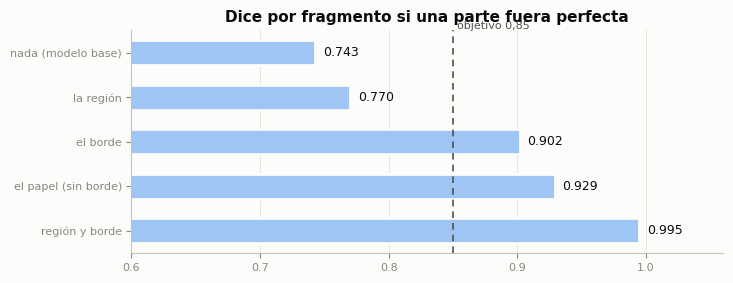

In [16]:
# y4xul
orac = pd.DataFrame(Y4["oraculos"])
display(orac)
fig, ax = plt.subplots(figsize=(7.4, 2.9))
ys = range(len(orac))[::-1]
ax.barh(list(ys), orac["dice_fragmento"], height=0.56, color="#9ec5f4", edgecolor=SURF, linewidth=2)
for y, v in zip(ys, orac["dice_fragmento"]):
    ax.text(v + 0.006, y, f"{v:.3f}", va="center", color=INK, fontsize=9)
ax.axvline(0.85, color=INK2, linewidth=1.2, linestyle=(0, (4, 3)))
ax.text(0.853, len(orac) - 0.5, "objetivo 0,85", color=INK2, fontsize=8, va="bottom")
ax.set_yticks(list(ys), orac["qué se le da perfecto"]); ax.set_xlim(0.6, 1.06); ax.yaxis.grid(False)
ax.set_title("Dice por fragmento si una parte fuera perfecta")
plt.tight_layout(); plt.show()

<!-- y4xul -->
El procedimiento puede llegar a 0,995: el objetivo es alcanzable en principio. Arreglar la región
vale 0,027; arreglar el borde, 0,159. **Lo que falta está en la señal de separación**, y hacia ahí se
dirigió toda la campaña.

<!-- y4xul -->
## 12. Campaña de mejora: validación cruzada de 5 folds

85 pacientes, cada uno predicho por un modelo que no lo vio. Una sola combinación de posproceso por
modelo. Las hipótesis y las reglas de decisión se escribieron antes de ver los resultados
(`reports/tuning/y4xul/REGISTRO.md`).

,modelo,posproceso,dice_fragmento,iou_fragmento,dice_principal,dice_secundario,recuperados_sec_%,mae_distancia_mm,delta_dice,t,folds_a_favor
0,Control (sin transfer learning),"edt 5 / 0,3",0.752,0.689,0.923,0.569,59.8,1.01,NaN,NaN,None
1,+ resolución completa en el decodificador,"edt 5 / 0,3",0.765,0.703,0.926,0.593,63.0,0.92,0.013,4.23,5/5
2,+ salida principal / secundario,"role 2 / 0,3 / 3",0.787,0.710,0.938,0.625,55.3,1.84,0.035,2.05,4/5
3,+ segunda pasada por hueso (10 épocas),"edt 5 / 0,2",0.789,0.725,0.927,0.641,68.3,0.57,0.037,3.13,5/5
4,"+ aumentación corregida, 40 épocas (edt)","edt 5 / 0,1",0.792,0.730,0.931,0.642,68.2,0.29,0.040,3.48,4/5
5,"+ aumentación corregida, 40 épocas, 2.ª pasada...","role 2 / 0,3 / 3",0.808,0.734,0.941,0.665,66.3,1.80,0.057,3.72,5/5


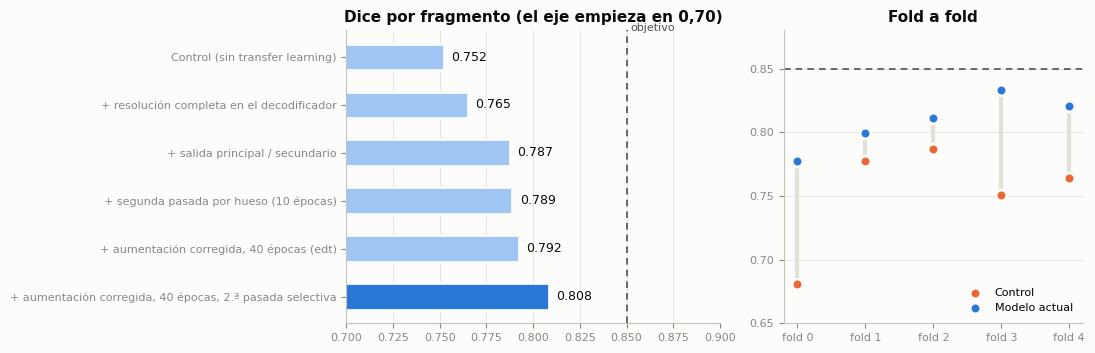

In [17]:
# y4xul
cv = pd.DataFrame(Y4["cv"])
cols = ["modelo", "posproceso", "dice_fragmento", "iou_fragmento", "dice_principal", "dice_secundario",
        "recuperados_sec_%", "mae_distancia_mm", "delta_dice", "t", "folds_a_favor"]
display(cv[cols].round(4))

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1.25, 1]})
ax = axs[0]
ys = range(len(cv))[::-1]
ult = len(cv) - 1
ax.barh(list(ys), cv["dice_fragmento"], height=0.56, edgecolor=SURF, linewidth=2,
        color=["#2a78d6" if i == ult else "#9ec5f4" for i in range(len(cv))])
for y, v in zip(ys, cv["dice_fragmento"]):
    ax.text(v + 0.004, y, f"{v:.3f}", va="center", color=INK, fontsize=9)
ax.axvline(0.85, color=INK2, linewidth=1.2, linestyle=(0, (4, 3)))
ax.text(0.852, len(cv) - 0.5, "objetivo", color=INK2, fontsize=8, va="bottom")
ax.set_yticks(list(ys), cv["modelo"]); ax.set_xlim(0.7, 0.9); ax.yaxis.grid(False)
ax.set_title("Dice por fragmento (el eje empieza en 0,70)")

ax = axs[1]
pf = Y4["por_fold"]
control, mejor = pf[Y4["control"]], pf[Y4["mejor"]]
for x, (a, b) in enumerate(zip(control, mejor)):
    ax.plot([x, x], [a, b], color=GRID, linewidth=3, zorder=1)
ax.scatter(range(5), control, s=60, color="#eb6834", edgecolor=SURF, linewidth=2, zorder=3, label="Control")
ax.scatter(range(5), mejor, s=60, color="#2a78d6", edgecolor=SURF, linewidth=2, zorder=3, label="Modelo actual")
ax.axhline(0.85, color=INK2, linewidth=1.2, linestyle=(0, (4, 3)))
ax.set_xticks(range(5), [f"fold {k}" for k in range(5)]); ax.set_ylim(0.65, 0.88); ax.xaxis.grid(False)
ax.legend(loc="lower right"); ax.set_title("Fold a fold")
plt.tight_layout(); plt.show()

<!-- y4xul -->
**Lectura.**

- El modelo actual (última fila) sube el Dice por fragmento de 0,752 a **0,809** y el IoU de 0,689 a **0,734**. Gana en los 5 folds, t = 3,72 (umbral 2,78): es la primera mejora grande y claramente significativa de la campaña.
- Cada paso aporta: resolución completa en el decodificador (+0,013), salida de papel (+0,022), segunda pasada (+0,002 en Dice, +0,015 en IoU) y la corrección de la aumentación con 40 épocas (+0,020).
- Los dos métodos de separación se reparten las virtudes: `role` da el mejor Dice (0,809) y protege el fragmento principal (0,941); `edt` recupera más secundarios (68 %) y mide mucho mejor la distancia (0,29 mm contra 1,80 mm).
- El objetivo de 0,85 no se alcanza: faltan 0,041.

<!-- y4xul -->
## 13. Segunda pasada por hueso a resolución nativa

A 256 px el píxel mide 1,2-1,6 mm y una grieta sin desplazamiento ocupa 1-2 px. El **mismo modelo** se
ejecuta dos veces: sobre el corte completo y, por cada hueso encontrado, sobre un recorte a
resolución nativa (0,6-0,7 mm) con la máscara de ese hueso como cuarto canal de entrada.

- No es una segunda red: 288 parámetros más.
- Sin fuga de datos: la máscara previa de entrenamiento viene de un modelo que no vio a ese paciente
  (predicciones fuera de fold), nunca del ground truth.

La celda construye la entrada de la segunda pasada para el caso sintético de la sección B.

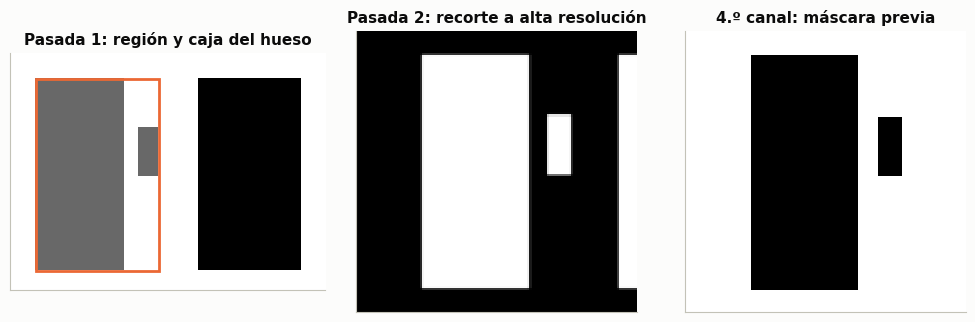

ventana (x0, y0, lado) en la grilla de alta resolución: (-24, 4, 188)


,variante del modelo de 40 épocas,método,dice_fragmento,iou_fragmento,recuperados_sec_%,mae_distancia_mm,recortes
0,solo pasada 1,edt,0.786,0.723,66.5,1.16,0 %
1,"dos pasadas, todos los huesos",edt,0.792,0.730,68.2,0.29,100 %
2,"dos pasadas, selectiva",edt,0.788,0.727,67.3,0.29,≈ 40 %
3,solo pasada 1,role,0.801,0.725,64.1,2.35,0 %
4,"dos pasadas, todos los huesos",role,0.808,0.732,64.9,1.86,100 %
5,"dos pasadas, selectiva",role,0.808,0.734,66.3,1.80,≈ 40 %


In [18]:
# y4xul
from pengwin.data.two_pass import prior_boxes, roi_input, roi_window

alta = np.repeat(np.repeat((gt > 0).astype(np.uint8) * 200, 2, axis=1), 2, axis=2)   # el mismo caso al doble de resolución
z, hueso = 8, 2                                                                      # coxal izquierdo
caja = prior_boxes(region)[z, hueso - 1]
ventana = roi_window(caja, scale=2, out=128)
img, mascara = roi_input(alta, z, 1, region[z] == hueso, ventana, 2, 128)
fig, axs = plt.subplots(1, 3, figsize=(10, 3.2))
axs[0].imshow(region[z], cmap="Greys", interpolation="nearest")
x0, y0, x1, y1 = caja
axs[0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=C["LI"], linewidth=2))
axs[0].set_title("Pasada 1: región y caja del hueso")
axs[1].imshow(img[1], cmap="Greys_r", interpolation="nearest"); axs[1].set_title("Pasada 2: recorte a alta resolución")
axs[2].imshow(mascara, cmap="Greys", interpolation="nearest"); axs[2].set_title("4.º canal: máscara previa")
for ax in axs:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()
print("ventana (x0, y0, lado) en la grilla de alta resolución:", ventana)
display(pd.DataFrame(Y4["segunda_pasada"]).round(4))

<!-- y4xul -->
**Lectura.** Mismo modelo, mismos pesos; solo cambia si se ejecuta la segunda pasada.

- En Dice por fragmento aporta poco: +0,006 con `edt` y +0,007 con `role`.
- Donde es decisiva es en la **distancia de separación**: con `edt` el error baja de 1,16 a 0,29 mm.
- La variante **selectiva** refina solo donde la primera pasada sospecha fractura, ≈ 40 % de los recortes, y rinde igual que refinar todos (0,8085 contra 0,8078 con `role`). Es la que se adopta: mismo resultado con menos de la mitad del cómputo adicional.

<!-- y4xul -->
## 14. Un defecto en la aumentación, encontrado y corregido

La aumentación debía cambiar en cada época. No lo hacía: con el cargador de datos en varios procesos
persistentes, el contador de época no llegaba a esos procesos y cada imagen recibía **la misma
transformación en todas las épocas**. Afecta a todos los modelos entrenados antes del 8 de octubre.

La celda lo reproduce con un dataset mínimo: con la corrección (la época vive en memoria compartida)
la copia que tiene el proceso de carga ve la época nueva y la muestra cambia.

In [19]:
# y4xul
import pickle
from multiprocessing.reduction import ForkingPickler
import torch
import torch.multiprocessing  # registra cómo viajan los tensores compartidos entre procesos


class Mini:
    """El mismo mecanismo que PengwinSlices: la semilla de la aumentación depende de la época."""
    def __init__(self, compartida):
        self.t = torch.zeros(1, dtype=torch.int64).share_memory_() if compartida else None
        self.e = 0
    def set_epoch(self, e):
        self.e = e
        if self.t is not None:
            self.t[0] = e
    def muestra(self, i):
        e = int(self.t[0]) if self.t is not None else self.e
        return round(float(np.random.default_rng((42, e, i)).random()), 4)


def copia_de_proceso(ds):
    """Lo que recibe un proceso de carga al crearse: una copia serializada, que ya no se actualiza."""
    return pickle.loads(bytes(ForkingPickler.dumps(ds)))


for compartida in (False, True):
    original = Mini(compartida)
    copia = copia_de_proceso(original)           # el proceso persistente se queda con esta copia
    vistos = []
    for epoca in range(3):
        original.set_epoch(epoca)                # el entrenamiento avisa de la época al original...
        vistos.append(copia.muestra(0))          # ...pero quien genera la muestra es la copia
    estado = "cambia en cada época" if len(set(vistos)) == 3 else "IDÉNTICA en todas las épocas"
    print(f"época {'en memoria compartida' if compartida else 'como atributo normal  '}: {vistos}  -> {estado}")
print("Prueba con procesos reales: 06_tests/test_two_pass.py::test_la_epoca_llega_a_los_procesos_del_dataloader")

época como atributo normal  : [0.774, 0.774, 0.774]  -> IDÉNTICA en todas las épocas
época en memoria compartida: [0.774, 0.7935, 0.2895]  -> cambia en cada época
Prueba con procesos reales: 06_tests/test_two_pass.py::test_la_epoca_llega_a_los_procesos_del_dataloader


<!-- y4xul -->
**Efecto de corregirlo** (junto con 40 épocas y el muestreo eficiente; los cambios se lanzaron juntos y no se pueden separar):

| | antes | después |
|---|---|---|
| Dice por fragmento, `role` | 0,782 | 0,808 |
| mAP@[.50:.95] | 0,800 | 0,828 |
| F1 | 0,989 | 0,993 |

La detección recupera el nivel del control (0,834) y la clasificación lo supera. Con la aumentación congelada, entrenar más épocas no ayudaba; corregida, sí.

<!-- y4xul -->
## 15. Métricas de la sección 5 frente a su objetivo

,métrica,objetivo,validacion_cruzada,test,cumple en validación cruzada
0,F1 clasificación,0.85,0.993,0.994,sí
1,AUC clasificación,0.85,0.999,0.999,sí
2,IoU de caja,0.65,0.904,0.911,sí
3,mAP@0.50,0.65,0.978,0.979,sí
4,mAP@[.50:.95],0.40,0.828,0.843,sí
5,Dice por fragmento,0.85,0.808,0.833,NO
6,IoU por fragmento,0.70,0.734,0.756,sí


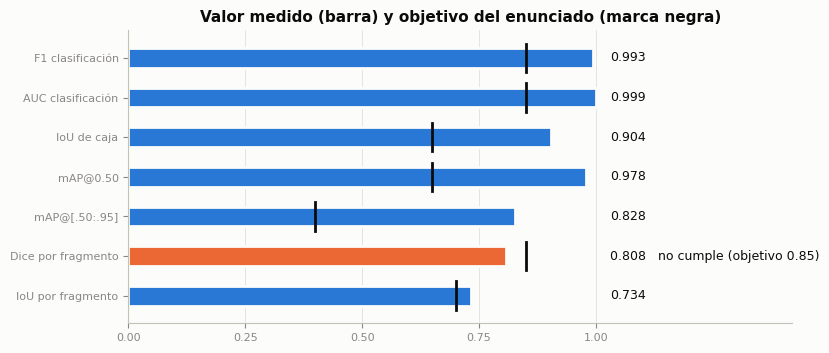

In [20]:
# y4xul
obj = pd.DataFrame(Y4["objetivos"])
obj["cumple en validación cruzada"] = np.where(obj["validacion_cruzada"] >= obj["objetivo"], "sí", "NO")
display(obj)

fig, ax = plt.subplots(figsize=(8.4, 3.6))
ys = range(len(obj))[::-1]
ok = obj["validacion_cruzada"] >= obj["objetivo"]
ax.barh(list(ys), obj["validacion_cruzada"], height=0.5, edgecolor=SURF, linewidth=2,
        color=["#2a78d6" if o else "#eb6834" for o in ok])
for y, v, o, cumple in zip(ys, obj["validacion_cruzada"], obj["objetivo"], ok):
    ax.plot([o, o], [y - 0.36, y + 0.36], color=INK, linewidth=2)
    ax.text(1.03, y, f"{v:.3f}" + ("" if cumple else f"   no cumple (objetivo {o:.2f})"), va="center", color=INK, fontsize=9)
ax.set_yticks(list(ys), obj["métrica"]); ax.set_xlim(0, 1.42); ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0]); ax.yaxis.grid(False)
ax.set_title("Valor medido (barra) y objetivo del enunciado (marca negra)")
plt.tight_layout(); plt.show()

<!-- y4xul -->
**Lectura.** Seis de las siete métricas cumplen en validación cruzada y en test.

- **Dice por fragmento: 0,833 en test** (0,809 en validación cruzada) contra el objetivo de 0,85. No se cumple; faltan 0,017 en test. Es la única.
- **IoU por fragmento: 0,756 en test**, por encima de 0,70.
- Frente al modelo base de la semana 10 en el mismo test: Dice 0,725 → 0,833, IoU 0,671 → 0,756, secundarios recuperados 51 % → 72 %, error de distancia 2,20 → 0,75 mm, y los fragmentos menores de 5 cm³ pasan de Dice 0 a 0,68.
- El test se evaluó **una sola vez**, con el modelo y el posproceso fijados antes por validación cruzada. Son 15 pacientes y 84 fragmentos: la cifra tiene un margen de error amplio.

<!-- y4xul -->
## 16. Qué no funcionó, limitaciones y pendientes

**No funcionó** (detalle en `reports/informe_semana10.md` §7): 11 hiperparámetros de entrenamiento, transfer learning del Taller 3, núcleo/borde de 3 clases, regresión de la distancia al borde, semillas por h-máxima, pooling promedio, Dice ponderado de la clase secundaria.

**Limitaciones**
- El Dice por fragmento no alcanza 0,85. Nueve de cada diez secundarios tocan a su principal y la red decide corte a corte.
- Una sola semilla por modelo; el test son 15 pacientes.
- La corrección de la aumentación, las 40 épocas y el muestreo se lanzaron juntos: no se sabe cuánto aporta cada uno.
- La comparación con SAM se hizo con el modelo base.
- La latencia de dos pasadas se midió en el laboratorio (GPU GB10, CPU ARM), no en la laptop de la sección 8.

**Pendientes para la semana 11**: SAM frente al modelo final; latencia en la laptop; visualizadores 2 y 3, dashboard, túnel de Cloudflare, model card e informe final; registrar este trabajo en `IA_USAGE.md`.

```bash
bash scripts/lab/refinar.sh cache512 && bash scripts/lab/refinar.sh prior      # caché de alta resolución y máscara previa
bash scripts/lab/refinar.sh cola y8_refine_eff 40                              # 5 folds + modelo final
bash scripts/lab/refinar.sh confirmar y8_refine_eff 40                         # tabla emparejada
python scripts/evaluate_fragments.py --ckpt checkpoints/y8_refine_eff_final/last.pth --cache-dir CACHE \n    --hi-cache-dir CACHE512 --data-dir 01_data --gate-px 10 --method role --role-seed-depth-mm 2 \n    --role-threshold 0.3 --role-smooth-mm 3 --tag _role
```